<a href="https://colab.research.google.com/github/jaumg2004/xGMobile/blob/main/Exercicio_Regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Exercícios de Regressão – Linear, Múltipla e Polinomial**


### 1. Regressão Linear Simples – Exercícios

**Exercício 1:**

Neste exercício, vamos gerar dados seguindo o modelo:

$$y = 3x + 2 + w,$$


onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e variância unitária.

O objetivo é ajustar um modelo de regressão linear e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.

---

**Exercício 2:**

Crie um conjunto de dados com $N = 100$ amostras seguindo o modelo:

$$y = \beta_0 + \beta_1 x + w,$$


onde:

- $x$ é um vetor coluna com $N$ elementos gerados a partir de uma distribuição **uniforme** no intervalo $[0, 10]$, representando os **anos de uso**;
- $\beta_0 = 50\,000$ é o preço inicial sem uso;
- $\beta_1 = -3\,000$ é a taxa de desvalorização por ano (relação linear decrescente);
- $w$ é um vetor coluna com $N$ elementos amostrados de uma **distribuição normal Gaussiana** com média zero e desvio padrão $\sigma = 2000$, representando ruído no preço.

Treine um modelo de regressão linear para estimar $\beta_0$ e $\beta_1$ e compare esses valores com os coeficientes reais. Plote a função original, os dados ruidosos e a reta estimada.

-----------------------------------------------------------
### 2. Regressão Linear Múltipla – Exercícios

**Exercício 3:**

Considere o modelo linear:

$$y = 5 + 3x_1 - 2x_2 + w,$$

onde:

- $x_1$ e $x_2$ são vetores coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é ajustar um modelo de regressão linear múltipla e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.

**Exercício 4:**

Neste exercício, vamos investigar o impacto da normalização quando trabalhamos com variáveis que possuem **escalas muito diferentes**.

Considere:

- $x_1$: variável na escala de **0 a 10**.  
- $x_2$: variável na escala de **0 a 10.000**.

O modelo real utilizado para gerar os dados será:

$$y = 4x_1 + 0.002x_2 + w,$$

onde o ruído $w$ segue uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 5$.

O objetivo é:

1. Treinar um **modelo sem normalização**.  
2. Treinar um **modelo com normalização via StandardScaler**.  
3. Comparar coeficientes e plotar a função original, os dados ruidosos e a reta estimada.  
4. Explicar por que a normalização impacta os coeficientes.

-----------------------------------------------------------
 ### 3. Regressão Polinomial – Exercícios

**Exercício 5:**
Considere o seguinte modelo gerador de dados:

$$
y = 2x^2 - x + 1 + w,
$$

onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é analisar o comportamento da regressão polinomial ao tentar aproximar um modelo não linear verdadeiro utilizando diferentes graus de complexidade.
Treine modelos de regressão polinomial considerando as seguintes hipóteses:

- Grau 1 (modelo linear):

$$
y \approx \beta_0 + \beta_1 x
$$

- Grau 2 (modelo correto em relação ao processo gerador):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2
$$

- Grau 3 (modelo superparametrizado):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3
$$

**Objetivo:**

Comparar o desempenho dos três modelos em termos de:

- capacidade de aproximação da função verdadeira;
- plotar a função original, os dados ruidosos e a reta estimada.
- impacto da complexidade do modelo (underfitting vs. overfitting);
- influência do termo de ruído $w$ na estimativa dos coeficientes.

In [52]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

#Exercício 1


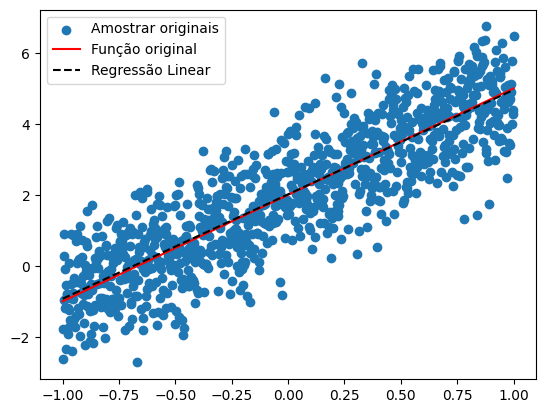

In [53]:
N = 1000
x = np.linspace(-1, 1, N)
w = np.random.normal(0, 1, N)
y = 3 * x + 2
y_noise = y + w

ln = LinearRegression()
ln.fit(x.reshape(-1, 1), y_noise)
y_pred = ln.predict(x.reshape(-1, 1))
plt.scatter(x, y_noise, label='Amostrar originais')
plt.plot(x, y, 'r', label='Função original')
plt.plot(x, y_pred, 'k--', label='Regressão Linear')
plt.legend()
plt.show()


#Exercício 2

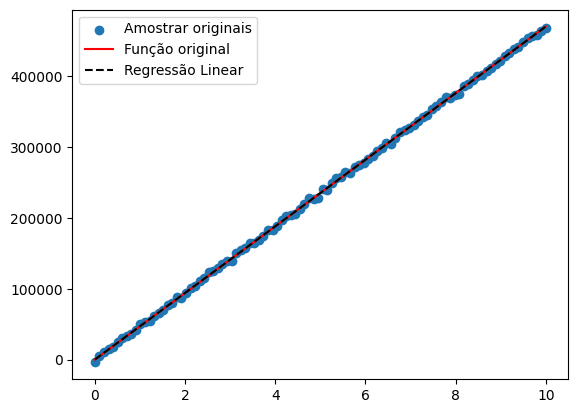

In [54]:
N = 100
x = np.linspace(0, 10, N)
w = np.random.normal(0, 2000, N)
y = 50000 * x - 3000 * x
y_noise = y + w

ln = LinearRegression()
ln.fit(x.reshape(-1, 1), y_noise)
y_pred = ln.predict(x.reshape(-1, 1))
plt.scatter(x, y_noise, label='Amostrar originais')
plt.plot(x, y, 'r', label='Função original')
plt.plot(x, y_pred, 'k--', label='Regressão Linear')
plt.legend()
plt.show()

#Exercício 3

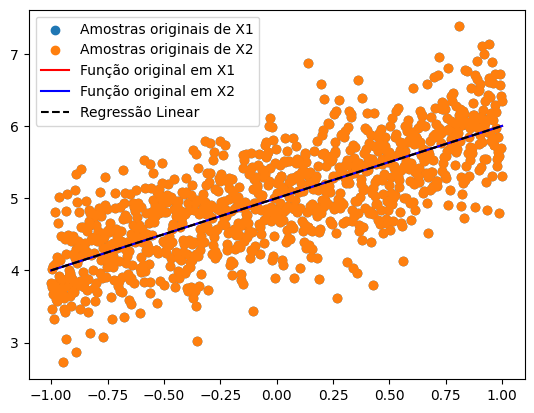

In [55]:
N = 1000
x1 = np.linspace(-1, 1, N)
x2 = np.linspace(-1, 1, N)
w = np.random.normal(0, 0.5, N)

y = 5 + 3 * x1 - 2 * x2
y_noise = y + w

ln = LinearRegression()
ln.fit(np.column_stack((x1, x2)), y)
y_pred = ln.predict(np.column_stack((x1, x2)))

plt.scatter(x1, y_noise, label='Amostras originais de X1')
plt.scatter(x2, y_noise, label='Amostras originais de X2')
plt.plot(x1, y, 'r', label='Função original em X1')
plt.plot(x2, y, 'b', label='Função original em X2')
plt.plot(x1, y_pred, 'k--', label='Regressão Linear')
plt.legend()
plt.show()


#Exercicío 4

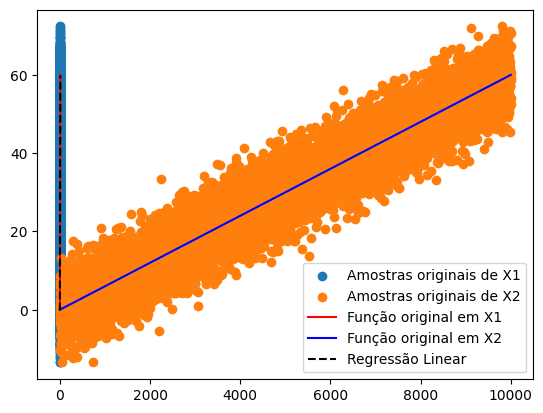

In [56]:
scaler = StandardScaler()

N = 10000
x1 = np.linspace(0, 10, N)
x2 = np.linspace(0, 10000, N)
w = np.random.normal(0, 5, N)

y = 4 * x1 + 0.002 * x2
y_noise = y + w

ln = LinearRegression()
ln.fit(np.column_stack((x1, x2)), y_noise)
y_pred_unscaled = ln.predict(np.column_stack((x1, x2)))

plt.scatter(x1, y_noise, label='Amostras originais de X1')
plt.scatter(x2, y_noise, label='Amostras originais de X2')
plt.plot(x1, y, 'r', label='Função original em X1')
plt.plot(x2, y, 'b', label='Função original em X2')
plt.plot(x1, y_pred_unscaled, 'k--', label='Regressão Linear')
plt.legend()
plt.show()

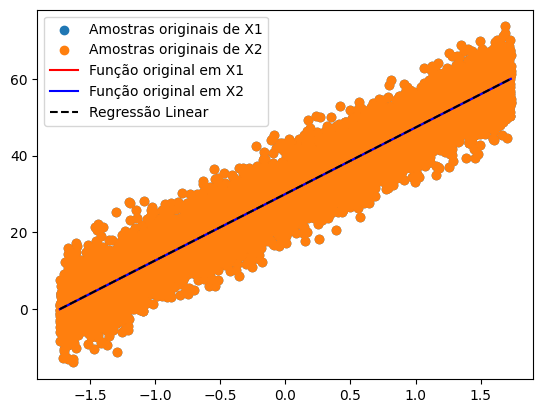

In [57]:
N = 10000
x1 = np.linspace(0, 10, N)
x2 = np.linspace(0, 10000, N)
w = np.random.normal(0, 5, N)

y = 4 * x1 + 0.002 * x2
y_noise = y + w


x1_scaled = scaler.fit_transform(x1.reshape(-1, 1))
x2_scaled = scaler.fit_transform(x2.reshape(-1, 1))

ln = LinearRegression()
ln.fit(np.column_stack((x1_scaled, x2_scaled)), y_noise)

y_pred = ln.predict(np.column_stack((x1_scaled, x2_scaled)))

plt.scatter(x1_scaled, y_noise, label='Amostras originais de X1')
plt.scatter(x2_scaled, y_noise, label='Amostras originais de X2')
plt.plot(x1_scaled, y, 'r', label='Função original em X1')
plt.plot(x2_scaled, y, 'b', label='Função original em X2')
plt.plot(x1_scaled, y_pred, 'k--', label='Regressão Linear')
plt.legend()
plt.show()

#Exercicío 5

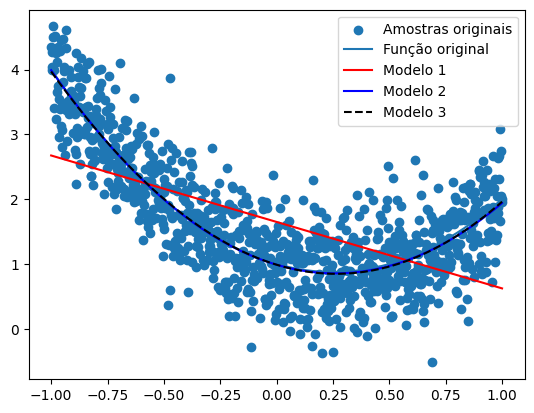

In [58]:
N = 1000
x = np.linspace(-1, 1, N)
w = np.random.normal(0, 0.5, N)
y = 2 * x ** 2 - x + 1
y_noise = y + w

ln = LinearRegression()
ln.fit(x.reshape(-1, 1), y_noise)
modelo1 = ln.predict(x.reshape(-1, 1))

pipeline1 = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('reg', LinearRegression())])
pipeline1.fit(x.reshape(-1, 1), y_noise)

modelo2 = pipeline1.predict(x.reshape(-1, 1))

pipeline2 = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('reg', LinearRegression())])
pipeline2.fit(x.reshape(-1, 1), y_noise)

modelo3 = pipeline2.predict(x.reshape(-1, 1))

plt.scatter(x, y_noise, label='Amostras originais')
plt.plot(x, y, label='Função original')
plt.plot(x, modelo1, 'r', label='Modelo 1')
plt.plot(x, modelo2, 'b', label='Modelo 2')
plt.plot(x, modelo3, 'k--', label='Modelo 3')
plt.legend()
plt.show()